In [1]:
IMAGE_SIZE = 320

In [2]:
import os
import yaml
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import BoundaryNorm
from PIL import Image

from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection, infer_device
from ultralytics import SAM

from torch.utils.data import Dataset
from torchvision import transforms

In [4]:
# Load the GroundingDINO model
model_dino_id = "IDEA-Research/grounding-dino-base"
device = infer_device()
processor = AutoProcessor.from_pretrained(model_dino_id)
model_dino = AutoModelForZeroShotObjectDetection.from_pretrained(model_dino_id).to(device)

# Load the SAM 2 model
model_sam2 = SAM("/home/c/choton/beemachine/codes/sam2_ultralytics_weights/sam2.1_b.pt")

In [5]:
def generate_full_body_mask(image_path, text_prompt):
    no_box, no_mask = False, False 
    try:
        image = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"Failed to open image: {image_path}, {e}")
        return None

    text_labels = [[text_prompt]]
    W, H = image.size
    nan_mask = np.full((H, W), np.nan, dtype=float)
    
    try:
        # Grounding DINO
        inputs = processor(images=image, text=text_labels, return_tensors="pt").to(model_dino.device)
        with torch.no_grad():
            outputs = model_dino(**inputs)

        results = processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            threshold=0.35,
            text_threshold=0.25,
            target_sizes=[image.size[::-1]]
        )       
        boxes = results[0].get("boxes", None)
    except Exception as e:
        print(f"GroundingDINO failure on {image_path}: {e}")
        boxes = None
        no_box = True    
    if boxes is None or len(boxes) == 0:
        # ← fallback: full-image box for SAM2
        # print("No object detected using DINO for image:", image_path)
        w, h = image.size
        box = np.array([0, 0, w, h], dtype=np.float32)
        no_box = True
    else:
        box = boxes[0].cpu().numpy()    
    try:
        # Use SAM 2 and generate masks
        results = model_sam2(image_path, bboxes=[box], verbose=False) # This will return a single, most confident mask for the given prompt
        masks = results[0].masks.data.cpu().numpy()
        if masks.shape[0] > 1: 
            # choose best mask, e.g. by area
            areas = [mask.sum() for mask in masks]
            idx = np.argmax(areas)
            mask = masks[idx]
        else:
            mask = masks[0]
    except Exception as e:
        print(f"SAM2 failure on {image_path}: {e}")
        mask = nan_mask
        no_mask = True
    if (mask is None) or (mask.size == 0) or (not mask.any()):
        print("No mask detected using SAM 2 for image:", image_path)
        mask = nan_mask
        no_mask = True
    return mask, no_box, no_mask #, image_mask

/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/ultralytics/models/sam/predict.py:318: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  bboxes = torch.as_tensor(bboxes, dtype=self.torch_dtype, device=self.device)


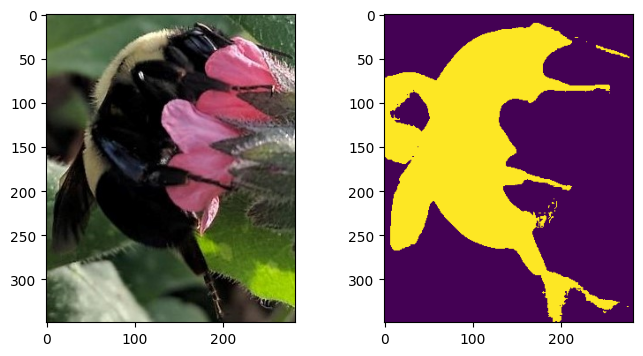

In [6]:
# Image path for zero-shot analysis
image_path = r"/home/c/choton/beemachine/datasets/dataset_small/Bombus_affinis/108QD0GQRSRKTK8KDKGKAK4K1KIKAKWQHSXKTK1QO01QLSEQ10WQDKVQY0UQRS2QNKRKAK4KLS1QLSNQCKVQHS5KJ08K.jpg"
text_prompt = r"bee"

image = Image.open(image_path)
mask, _, _ = generate_full_body_mask(image_path, text_prompt)
fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].imshow(image)
axes[1].imshow(mask)

In [7]:
# Paths
DATA_DIR = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5/"
yaml_path = os.path.join(DATA_DIR, 'data.yaml') # "/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/data.yaml"
images_dir = os.path.join(DATA_DIR, 'train', 'aug_images') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/images"
yolo_labels_dir = os.path.join(DATA_DIR, 'train', 'aug_labels') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/LABELS"
images = os.listdir(images_dir) # Get the list of images
images.sort() # Sorting images based on the name

In [8]:
def get_spectrum_colors(class_ids, cmap_name="viridis"):
    class_ids = sorted(class_ids)
    cmap = plt.get_cmap(cmap_name)
    n = len(class_ids)

    return {
        cid: cmap(i / max(n - 1, 1))[:3]  # drop alpha
        for i, cid in enumerate(class_ids)
    }

# Load class names from YAML
with open(yaml_path, 'r') as file:
    # Use safe_load for security, as it prevents arbitrary code execution
    config = yaml.safe_load(file)
print(config)
LABELS = config['names']
if 'background' not in LABELS:
    LABELS.insert(0, 'background')
print(LABELS)
CLASS_COLORS = get_spectrum_colors(range(len(LABELS)), "turbo")

# Function to plot mask annotation
def plot_mask_annotation(image, mask, ax, labels=LABELS, class_colors=CLASS_COLORS):
    np.random.seed(30) # Same color everytime
    mask_np = np.array(mask)
    ax.set_title("Fixed mask annotations")
    ax.imshow(image)
    class_ids = np.unique(mask_np)
    # class_ids = class_ids[class_ids != 0]    
    color_mask = np.zeros((*mask_np.shape, 3), dtype=float)
    for cid in class_ids:
        color_mask[mask_np == cid] = class_colors[cid]
    ax.imshow(color_mask, alpha=0.5)    
    for cid in class_ids:
        ax.plot([], [], color=class_colors[cid], label=f"{cid}: {labels[cid]}")
    ax.legend()

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 3, 'names': ['abdomen', 'head', 'thorax'], 'roboflow': {'workspace': 'test-f3zdy', 'project': 'beemachine-aqnj1', 'version': 10, 'license': 'MIT', 'url': 'https://universe.roboflow.com/test-f3zdy/beemachine-aqnj1/dataset/10'}}
['background', 'abdomen', 'head', 'thorax']


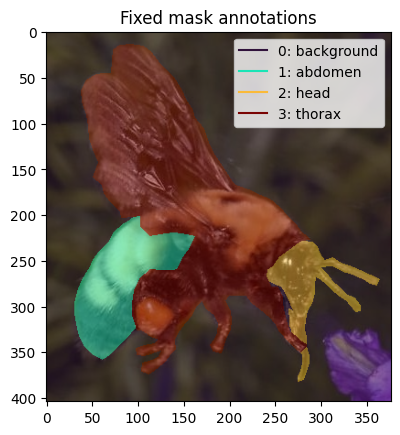

In [9]:
fig, axes = plt.subplots(1, 1)
image_file = images[204]
image_path = os.path.join(images_dir, image_file)
mask_path = os.path.join(DATA_DIR, 'train', 'aug_masks', image_file[:-4] + "_m.png")
image = Image.open(image_path)
mask = Image.open(mask_path).convert("L")  # class-index mask
plot_mask_annotation(image, mask, axes)

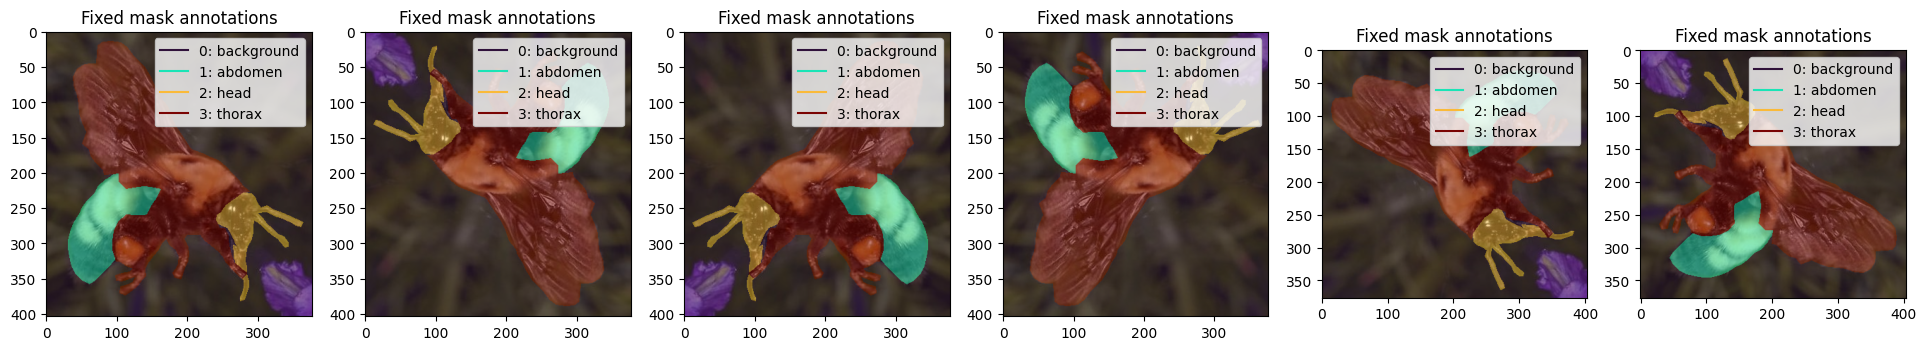

In [11]:
fig, axes = plt.subplots(1, 6, figsize=(24,4))
for i in range(6):
    image_file = images[204+i]
    image_path = os.path.join(images_dir, image_file)
    mask_path = os.path.join(DATA_DIR, 'train', 'aug_masks', image_file[:-4] + "_m.png")
    image = Image.open(image_path)
    mask = Image.open(mask_path).convert("L")  # class-index mask
    plot_mask_annotation(image, mask, axes[i])

/tmp/ipykernel_1262640/1682478220.py:35: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  ax.plot([], [], color=class_colors[cid], label=f"{cid}: {labels[cid]}")


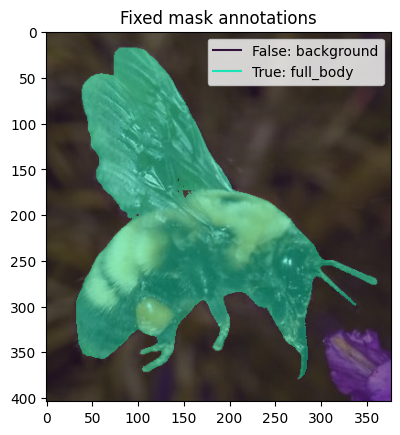

In [12]:
fig, axes = plt.subplots(1, 1)
image_file = images[204]
image_path = os.path.join(images_dir, image_file)
image = Image.open(image_path)
mask, _, _ = generate_full_body_mask(image_path, text_prompt)
plot_mask_annotation(image, mask, axes, labels=['background','full_body'])

Now perform zeroshot masking from dataset

In [13]:
class ImageOnlyDataset(Dataset):
    def __init__(self, root, images_dir="images", image_size=320):
        self.images_dir = os.path.join(root, images_dir)
        self.image_paths = sorted([
            os.path.join(self.images_dir, f)
            for f in os.listdir(self.images_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            # ⚠️ Use SAME normalization as training
            # transforms.Normalize(mean=..., std=...)
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return img, path

In [14]:
# Load the datasets
home_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5/"
train_path = os.path.join(home_path, "train") # Path for the training data
val_path = os.path.join(home_path, "valid") # Path for validation data
test_path = os.path.join(home_path, "test") # Path for testing data

train_dataset = ImageOnlyDataset(root=train_path, images_dir='aug_images', image_size=IMAGE_SIZE)
val_dataset = ImageOnlyDataset(root=val_path, image_size=IMAGE_SIZE)
test_dataset = ImageOnlyDataset(root=test_path, image_size=IMAGE_SIZE)

print(f"Images in dataset, train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")

Images in dataset, train: 34722, val: 1158, test: 771


/tmp/ipykernel_1262640/1682478220.py:35: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  ax.plot([], [], color=class_colors[cid], label=f"{cid}: {labels[cid]}")


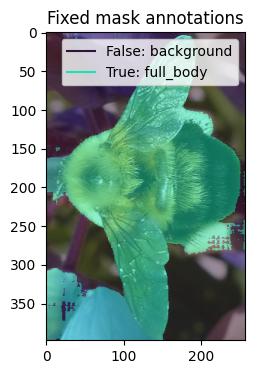

In [15]:
# Get sample image and mask
fig, axes = plt.subplots(1, 1, figsize=(8,4))
img, image_path = train_dataset[1522]
image = Image.open(image_path)
mask, _, _ = generate_full_body_mask(image_path, text_prompt)
plot_mask_annotation(image, mask, axes, labels=['background','full_body'])

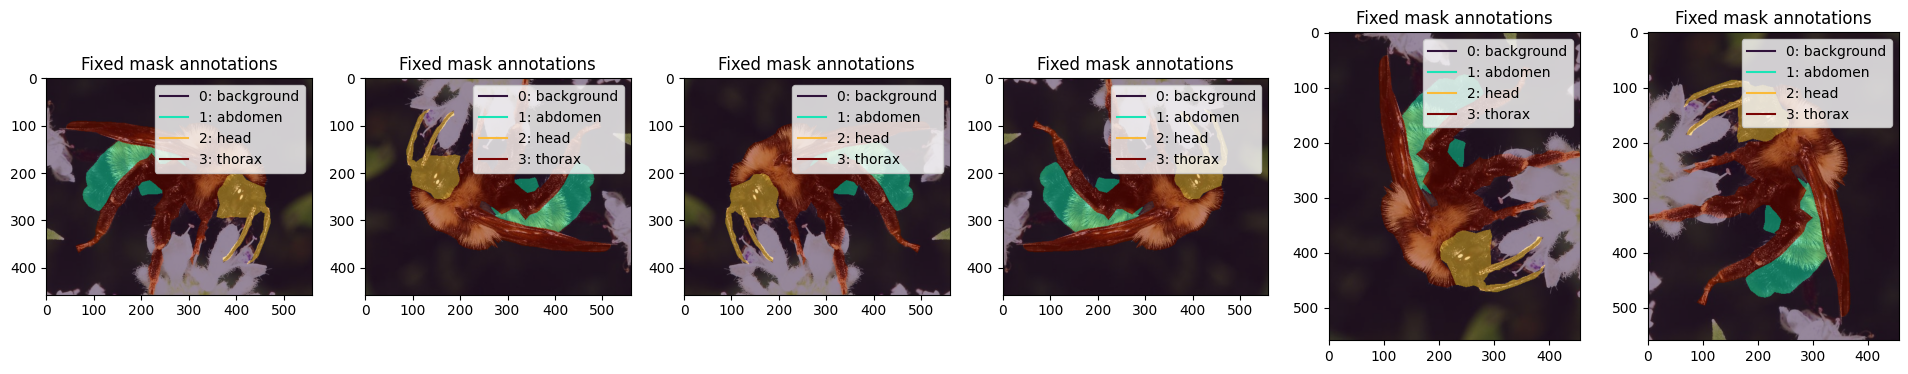

In [16]:
fig, axes = plt.subplots(1, 6, figsize=(24,4))
for i in range(6):
    _, image_path = train_dataset[240+i]
    image_file = os.path.basename(image_path)
    mask_path = os.path.join(DATA_DIR, 'train', 'aug_masks', image_file[:-4] + "_m.png")
    image = Image.open(image_path)
    mask = Image.open(mask_path).convert("L")  # class-index mask
    plot_mask_annotation(image, mask, axes[i])

/tmp/ipykernel_1262640/1682478220.py:35: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  ax.plot([], [], color=class_colors[cid], label=f"{cid}: {labels[cid]}")


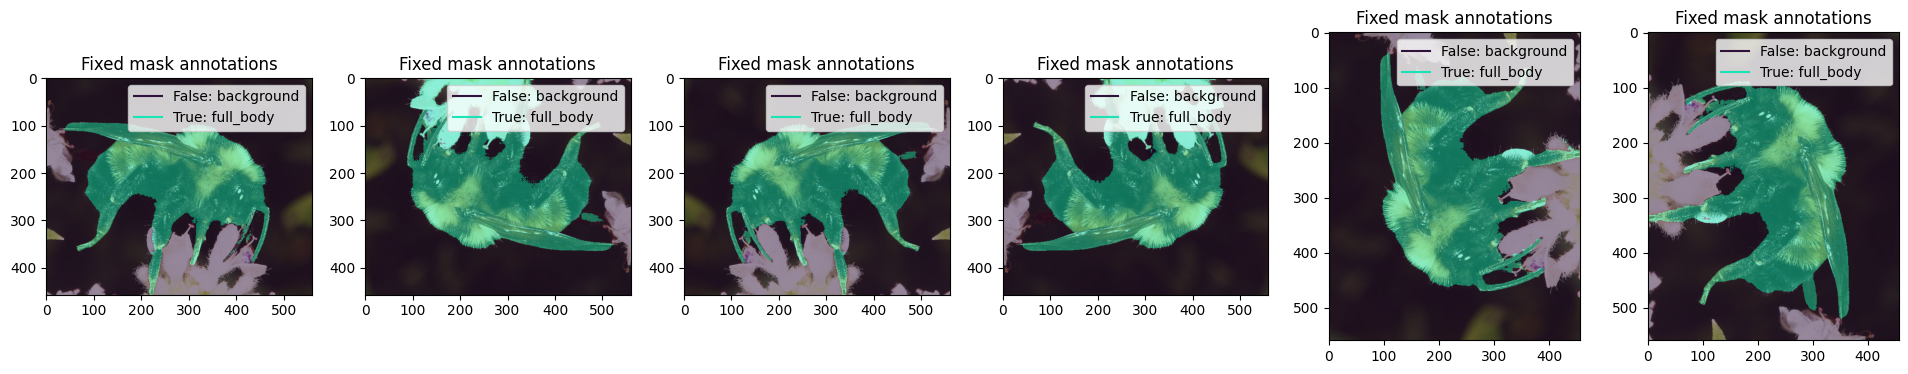

In [17]:
fig, axes = plt.subplots(1, 6, figsize=(24,4))
for i in range(6):
    _, image_path = train_dataset[240+i]
    image = Image.open(image_path)
    mask, _, _ = generate_full_body_mask(image_path, text_prompt)
    plot_mask_annotation(image, mask, axes[i], labels=['background','full_body'])